<a href="https://colab.research.google.com/github/Madankk-06/Generative_AI_Projects/blob/main/6_High_Throughput_Asynchronous_RAG_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q sentence-transformers
!pip install -q faiss-cpu
!pip install -q langchain

In [2]:
print('Upgrading transformers library...')
!pip install --upgrade transformers

Upgrading transformers library...


In [3]:
import asyncio
import time
import faiss
import numpy as np

from sentence_transformers import SentenceTransformer
from sentence_transformers import CrossEncoder

In [4]:
documents = [
    "Python is a programming language.",
    "Transformers are used for NLP.",
    "Retrieval Augmented Generation combines retrieval with LLMs.",
    "FAISS performs vector similarity search.",
    "FastAPI supports asynchronous APIs.",
    "Sentence Transformers generate embeddings.",
    "Cross Encoder reranks retrieved documents.",
    "Attention is the key component of Transformers.",
    "Large Language Models generate text.",
    "LangChain helps develop LLM applications."
]

In [5]:
bi_encoder = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = bi_encoder.encode(
    documents,
    convert_to_numpy=True
)

print(embeddings.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

(10, 384)


In [6]:
dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)

index.add(
    embeddings.astype(np.float32)
)

print("Documents Indexed:", index.ntotal)

Documents Indexed: 10


In [7]:
cross_encoder = CrossEncoder(
    "cross-encoder/ms-marco-MiniLM-L-6-v2"
)

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 90.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

In [8]:
async def rag_pipeline(query, top_k=5):

    start = time.time()

    query_embedding = bi_encoder.encode(
        [query],
        convert_to_numpy=True
    )

    distances, indices = index.search(
        query_embedding.astype(np.float32),
        top_k
    )

    retrieved = [
        documents[i]
        for i in indices[0]
    ]

    pairs = [[query, doc] for doc in retrieved]

    scores = cross_encoder.predict(pairs)

    ranked = sorted(
        zip(retrieved, scores),
        key=lambda x: x[1],
        reverse=True
    )

    latency = time.time() - start

    return ranked, latency

In [9]:
results, latency = await rag_pipeline(
    "Explain Retrieval Augmented Generation"
)

print("Latency:", latency)

for doc, score in results:
    print(f"{score:.4f}  {doc}")

Latency: 0.10675668716430664
5.8182  Retrieval Augmented Generation combines retrieval with LLMs.
-10.6247  Cross Encoder reranks retrieved documents.
-11.3806  Sentence Transformers generate embeddings.
-11.3975  FAISS performs vector similarity search.
-11.4038  Large Language Models generate text.


In [10]:
queries = [
    "Python",
    "FAISS",
    "Transformers",
    "LangChain",
    "Attention"
]

async def worker(q):

    results, latency = await rag_pipeline(q)

    return {
        "query": q,
        "top_document": results[0][0],
        "score": float(results[0][1]),
        "latency": latency
    }

responses = await asyncio.gather(
    *[worker(q) for q in queries]
)

for r in responses:
    print(r)

{'query': 'Python', 'top_document': 'Python is a programming language.', 'score': 8.698076248168945, 'latency': 0.06134033203125}
{'query': 'FAISS', 'top_document': 'FAISS performs vector similarity search.', 'score': 7.4265947341918945, 'latency': 0.055136680603027344}
{'query': 'Transformers', 'top_document': 'Transformers are used for NLP.', 'score': 4.605255603790283, 'latency': 0.06574892997741699}
{'query': 'LangChain', 'top_document': 'LangChain helps develop LLM applications.', 'score': 7.895220756530762, 'latency': 0.08231616020202637}
{'query': 'Attention', 'top_document': 'Attention is the key component of Transformers.', 'score': 6.738245964050293, 'latency': 0.05843234062194824}


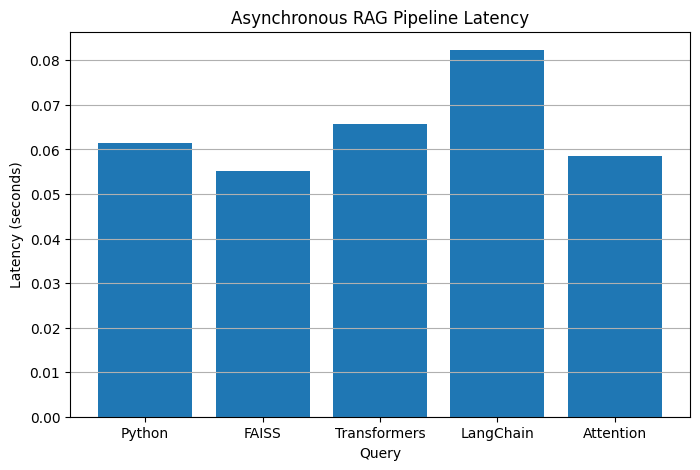

In [11]:
import matplotlib.pyplot as plt

latencies = [r["latency"] for r in responses]

plt.figure(figsize=(8,5))
plt.bar(range(len(queries)), latencies)
plt.xticks(range(len(queries)), queries)
plt.xlabel("Query")
plt.ylabel("Latency (seconds)")
plt.title("Asynchronous RAG Pipeline Latency")
plt.grid(axis="y")
plt.show()